## Covariance “sky plate” visualization

This notebook visualizes the predicted on-sky covariance at three example epochs and compares the *physical* selection shapes used by the three healpixel-selection strategies:

- **disc**: conservative circle bound from major-axis sigma (`covariance`)
- **mc**: sampled variants from sky covariance (`covariance_mc`)
- **polygon**: explicit N-sigma ellipse boundary polygon (`covariance_polygon`)

All plots are in a local tangent-plane basis:

- \(x = \Delta\mathrm{RA} \cos(\mathrm{Dec}_0)\) (degrees)
- \(y = \Delta\mathrm{Dec}\) (degrees)

where (RA0, Dec0) is the nominal prediction at that epoch.

In [42]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from adam_assist import ASSISTPropagator
from adam_core.orbits import Orbits
from adam_core.observers import Observers
from adam_core.dynamics.propagation import propagate_2body
from adam_core.dynamics.ephemeris import generate_ephemeris_2body

# Make matplotlib deterministic-ish and avoid writing to ~/.matplotlib
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-cache")

plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=4, suppress=True)

In [43]:
# Load a sample orbit with covariance from the test data
orbits = Orbits.from_parquet("tests/data/sample_orbits.parquet")
orbit = orbits[0:1]

# Pick an observatory code used in the tests
obscode = "I41"

# Choose three epochs: start, +2 weeks, +1 month (MJD UTC)
mjd_start = 50000.0
mjds = np.array([mjd_start, mjd_start + 14.0, mjd_start + 30.0], dtype=float)
times = orbit.coordinates.time.from_mjd(mjds, scale="utc")

# Propagation strategy consistent with precovery:
# 1) ASSIST to mean epoch (with covariance)
# 2) 2-body to each epoch
# 3) generate topocentric ephemeris (with covariance)
mean_time = orbit.coordinates.time.from_mjd([float(mjds.mean())], scale="utc")
prop = ASSISTPropagator()
mean_orbit = prop.propagate_orbits(orbit, mean_time, covariance=True)
propagated = propagate_2body(mean_orbit, times)
observers = Observers.from_code(obscode, times)
eph = generate_ephemeris_2body(propagated, observers)

assert eph.coordinates.covariance is not None and not eph.coordinates.covariance.is_all_nan()
print("Ephemeris rows:", len(eph))
print("Epochs: MJD", mjds[0], f"(start), {mjds[1]} (+2 weeks), {mjds[2]} (+1 month)")
print("Example RA/Dec:", eph.coordinates.lon[0].as_py(), eph.coordinates.lat[0].as_py())

Ephemeris rows: 3
Epochs: MJD 50000.0 (start), 50014.0 (+2 weeks), 50030.0 (+1 month)
Example RA/Dec: 205.8891202290771 -15.381234526875756


In [ ]:
def wrap_dlon_deg(lon_deg, lon0_deg):
    """Wrap (lon - lon0) into [-180, 180) degrees."""
    return (lon_deg - lon0_deg + 180.0) % 360.0 - 180.0


def cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0_deg):
    """Map 2x2 covariance in (lon, lat) to tangent-plane (x=dlon*cos(lat0), y=dlat)."""
    c = float(np.cos(np.deg2rad(lat0_deg)))
    A = np.array([[c, 0.0], [0.0, 1.0]], dtype=float)
    return A @ cov_ll_deg2 @ A.T


def ellipse_boundary_from_cov(cov_xy_deg2, n_sigma=3.0, num=128):
    """Return points on the N-sigma ellipse in the tangent plane."""
    cov = 0.5 * (cov_xy_deg2 + cov_xy_deg2.T)
    w, v = np.linalg.eigh(cov)
    w = np.maximum(w, 0.0)
    # sqrt(cov) = V sqrt(W) V^T
    S = v @ np.diag(np.sqrt(w)) @ v.T
    t = np.linspace(0.0, 2.0 * np.pi, int(num), endpoint=True)
    unit = np.stack([np.cos(t), np.sin(t)], axis=1)
    pts = (unit @ S.T) * float(n_sigma)
    return pts  # (num, 2)


def disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=3.0):
    """Fast disc bound (major-axis sigma) -> healpix pixels.

    Returns both:
    - r_cov_rad: the covariance-only radius (physical N-sigma circle in the tangent plane)
    - r_query_rad: the actual radius used for healpix querying (adds a pixel-margin)
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    w = np.linalg.eigvalsh(0.5 * (cov_xy + cov_xy.T))
    lam_max = float(np.max(np.maximum(w, 0.0)))
    sigma_major_deg = float(np.sqrt(lam_max))

    r_cov_rad = np.deg2rad(float(n_sigma) * sigma_major_deg)
    r_query_rad = r_cov_rad + float(hp.max_pixrad(nside))

    vec = hp.ang2vec(lon0, lat0, lonlat=True)
    pix = hp.query_disc(nside, vec, r_query_rad, inclusive=True, nest=True)
    pix_set = set(int(p) for p in np.asarray(pix).ravel().tolist())
    
    # NO neighbors added (user request: remove neighbor inclusion)
    return pix_set, r_cov_rad, r_query_rad


def ellipse_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=3.0, num_vertices=256, fact=8):
    """Ellipse-based healpixel selection using the *area* of the N-sigma covariance ellipse.

    This fixes the previous implementation which only checked pixel centers.

    Approach:
    - Build a high-resolution polygon approximation of the ellipse boundary (num_vertices points)
    - Use `healpy.query_polygon(..., inclusive=True)` to return pixels intersecting the polygon AREA

    Returns
    -------
    pix_set : set[int]
        Healpixels intersecting the ellipse area.
    sigma_major_deg, sigma_minor_deg : float
        1-sigma semi-axis lengths in the tangent plane (degrees), before multiplying by n_sigma.
    pts_xy : np.ndarray
        Ellipse boundary points in tangent plane (degrees), shape (V, 2).
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)

    # Eigen-decomposition for semi-axis lengths
    w, v = np.linalg.eigh(0.5 * (cov_xy + cov_xy.T))
    w = np.maximum(w, 0.0)
    sigma_minor_deg = float(np.sqrt(w[0]))
    sigma_major_deg = float(np.sqrt(w[1]))

    # High-res ellipse boundary in tangent plane
    angles = np.linspace(0.0, 2.0 * np.pi, int(num_vertices), endpoint=False)
    unit = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    S = v @ np.diag(np.sqrt(w)) @ v.T
    pts_xy = (unit @ S.T) * float(n_sigma)

    # If the ellipse is tiny relative to the pixel size, it can trip healpy's
    # "degenerate corner" handling. In that case the correct intersection is just
    # the center pixel.
    pixel_size_deg = float(np.rad2deg(hp.nside2resol(nside)))
    extent_deg = float(np.max(np.linalg.norm(pts_xy, axis=1))) if len(pts_xy) else 0.0
    if extent_deg > 0 and extent_deg < 0.05 * pixel_size_deg:
        center_pix = int(hp.ang2pix(nside, lon0, lat0, lonlat=True, nest=True))
        return {center_pix}, sigma_major_deg, sigma_minor_deg, pts_xy

    # Convert tangent-plane points to (lon, lat)
    cos_lat = float(np.cos(np.deg2rad(lat0)))
    cos_lat = cos_lat if np.isfinite(cos_lat) and abs(cos_lat) > 1e-12 else 1e-12
    dlon = pts_xy[:, 0] / cos_lat
    dlat = pts_xy[:, 1]
    lon_poly = (lon0 + dlon) % 360.0
    lat_poly = np.clip(lat0 + dlat, -89.999999, 89.999999)

    # healpy.query_polygon expects vertices of shape (N, 3)
    verts = np.asarray(hp.ang2vec(lon_poly, lat_poly, lonlat=True), dtype=float)
    # Some healpy builds may return (3, N); normalize to (N, 3)
    if verts.ndim == 2 and verts.shape[0] == 3 and verts.shape[1] != 3:
        verts = verts.T
    verts = np.ascontiguousarray(verts, dtype=float)
    if verts.ndim != 2 or verts.shape[1] != 3:
        raise ValueError(f"Expected vertices shape (N, 3), got {verts.shape}")

    try:
        pix = hp.query_polygon(nside, verts, inclusive=True, fact=int(fact), nest=True)
        pix_set = set(int(p) for p in np.asarray(pix).ravel().tolist())
    except Exception:
        # Fallback: boundary pixels only (still a decent approximation for small regions)
        pix_v = hp.ang2pix(nside, lon_poly, lat_poly, lonlat=True, nest=True)
        pix_set = set(int(p) for p in np.asarray(pix_v).ravel().tolist())

    # NO neighbors added
    return pix_set, sigma_major_deg, sigma_minor_deg, pts_xy


def mc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=3.0, num_samples=256, seed=0):
    """Monte Carlo healpixel selection.

    Returns *all* healpixels that contain at least one sampled point.

    Notes:
    - Samples are drawn in the local tangent plane from the covariance (scaled by n_sigma).
    - We also include the nominal predicted point pixel.
    - NO neighbors added.
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    cov_xy = 0.5 * (cov_xy + cov_xy.T)

    # Robust sqrt (matches spirit of precovery_db: safe factorization)
    w, v = np.linalg.eigh(cov_xy)
    w = np.maximum(w, 0.0)
    L = v @ np.diag(np.sqrt(w))

    rng = np.random.default_rng(int(seed))
    z = rng.standard_normal((int(num_samples), 2))
    dxy = (z @ L.T) * float(n_sigma)

    cos_lat = float(np.cos(np.deg2rad(lat0)))
    cos_lat = cos_lat if np.isfinite(cos_lat) and abs(cos_lat) > 1e-12 else 1e-12
    dlon = dxy[:, 0] / cos_lat
    dlat = dxy[:, 1]

    lon_s = (lon0 + dlon) % 360.0
    lat_s = np.clip(lat0 + dlat, -89.999999, 89.999999)

    # Always include the nominal predicted point
    lon_all = np.concatenate([lon_s, np.array([lon0], dtype=float)])
    lat_all = np.concatenate([lat_s, np.array([lat0], dtype=float)])

    pix = hp.ang2pix(nside, lon_all, lat_all, lonlat=True, nest=True)
    pix_set = set(int(p) for p in np.asarray(pix).ravel().tolist())

    return pix_set, dxy


def polygon_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=3.0, num_vertices=32, fact=8):
    """Polygon method: return healpixels intersecting the polygon AREA.

    We approximate the N-sigma ellipse boundary with `num_vertices` points and call
    `healpy.query_polygon(..., inclusive=True)`.

    This returns pixels intersecting the polygon area (not just boundary).
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    pts = ellipse_boundary_from_cov(cov_xy, n_sigma=n_sigma, num=num_vertices)

    # Tiny polygons can trigger healpy "degenerate corner"; in that case the correct
    # intersection is the center pixel.
    pixel_size_deg = float(np.rad2deg(hp.nside2resol(nside)))
    extent_deg = float(np.max(np.linalg.norm(pts, axis=1))) if len(pts) else 0.0
    if extent_deg > 0 and extent_deg < 0.05 * pixel_size_deg:
        center_pix = int(hp.ang2pix(nside, lon0, lat0, lonlat=True, nest=True))
        return {center_pix}, pts

    cos_lat = float(np.cos(np.deg2rad(lat0)))
    cos_lat = cos_lat if np.isfinite(cos_lat) and abs(cos_lat) > 1e-12 else 1e-12
    dlon = pts[:, 0] / cos_lat
    dlat = pts[:, 1]
    lon_poly = (lon0 + dlon) % 360.0
    lat_poly = np.clip(lat0 + dlat, -89.999999, 89.999999)

    verts = np.asarray(hp.ang2vec(lon_poly, lat_poly, lonlat=True), dtype=float)
    if verts.ndim == 2 and verts.shape[0] == 3 and verts.shape[1] != 3:
        verts = verts.T
    verts = np.ascontiguousarray(verts, dtype=float)
    if verts.ndim != 2 or verts.shape[1] != 3:
        raise ValueError(f"Expected vertices shape (N, 3), got {verts.shape}")

    try:
        pix = hp.query_polygon(nside, verts, inclusive=True, fact=int(fact), nest=True)
        pix_set = set(int(p) for p in np.asarray(pix).ravel().tolist())
    except Exception:
        # Fallback: boundary pixels only
        pix_v = hp.ang2pix(nside, lon_poly, lat_poly, lonlat=True, nest=True)
        pix_set = set(int(p) for p in np.asarray(pix_v).ravel().tolist())

    # NO neighbors added
    return pix_set, pts


def pixel_boundaries_tangent_xy(pix, nside, lon0, lat0):
    """Return boundary vertices for a HEALPix pixel in tangent-plane coordinates."""
    b = hp.boundaries(nside, int(pix), step=1, nest=True)  # (3, Nv)
    lon_b, lat_b = hp.vec2ang(b.T, lonlat=True)
    dx = wrap_dlon_deg(lon_b, lon0) * np.cos(np.deg2rad(lat0))
    dy = (lat_b - lat0)
    return dx, dy


def plot_case(ax, lon0, lat0, cov_ll_deg2, nside=32, n_sigma=3.0, num_vertices=32, mc_samples=256, mc_seed=0):
    """Combined view: all methods on one axis."""
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)

    # Covariance ellipse (physical N-sigma boundary)
    ell = ellipse_boundary_from_cov(cov_xy, n_sigma=n_sigma, num=256)

    # Disc
    disc_set, r_cov_rad, r_query_rad = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
    t = np.linspace(0, 2*np.pi, 200)
    r_cov_deg = np.rad2deg(r_cov_rad)
    r_query_deg = np.rad2deg(r_query_rad)

    # MC
    mc_set, mc_dxy = mc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma, num_samples=mc_samples, seed=mc_seed)

    # Polygon
    poly_set, poly_pts = polygon_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma, num_vertices=num_vertices)

    # Draw HEALPix grid with method-specific highlights
    union = sorted(disc_set | mc_set | poly_set)
    for p in union:
        dx, dy = pixel_boundaries_tangent_xy(p, nside, lon0, lat0)
        # Color-code by which method(s) selected this pixel
        in_disc = p in disc_set
        in_mc = p in mc_set
        in_poly = p in poly_set
        
        if in_disc and in_mc and in_poly:
            color = "#e6ffe6"  # light green - all three
            edge = "#2ca02c"
            lw = 1.2
        elif in_mc and in_poly:
            color = "#fff0e6"  # light orange - MC + polygon
            edge = "#ff7f0e"
            lw = 1.0
        elif in_disc:
            color = "#e6f2ff"  # light blue - disc only
            edge = "#1f77b4"
            lw = 0.8
        else:
            color = "0.95"
            edge = "0.7"
            lw = 0.5
        
        ax.fill(dx, dy, color=color, edgecolor=edge, lw=lw, zorder=0, alpha=0.7)

    # Plot elements with better visibility
    ax.plot(ell[:, 0], ell[:, 1], color="k", lw=3.0, label=f"{n_sigma}σ ellipse", zorder=5)
    ax.plot(r_cov_deg*np.cos(t), r_cov_deg*np.sin(t), color="#1f77b4", lw=2.5, ls="--", alpha=0.9, label="disc bound", zorder=4)
    ax.plot(poly_pts[:, 0], poly_pts[:, 1], color="#2ca02c", lw=2.5, label="polygon boundary", zorder=4)
    ax.scatter(mc_dxy[:, 0], mc_dxy[:, 1], s=8, alpha=0.3, color="#ff7f0e", label="MC samples", zorder=3)
    ax.scatter([0.0], [0.0], color="red", s=80, marker="x", linewidths=3, label="nominal position", zorder=6)

    ell_scale = float(np.max(np.abs(ell))) if ell.size else 1e-6
    lim = max(1.5 * ell_scale, 1.5 * r_cov_deg, 1e-6)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x = ΔRA cos(Dec₀) [deg]", fontsize=11)
    ax.set_ylabel("y = ΔDec [deg]", fontsize=11)
    ax.set_title(f"RA₀={lon0:.3f}°, Dec₀={lat0:.3f}°\nHealpixels: all={len(union)}, disc={len(disc_set)}, MC={len(mc_set)}, poly={len(poly_set)}", 
                 fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3, ls=":", lw=0.5)

    return disc_set, mc_set, poly_set, r_cov_deg, r_query_deg


def plot_case_separated(
    axes_row,
    lon0,
    lat0,
    cov_ll_deg2,
    nside=32,
    n_sigma=3.0,
    num_vertices=32,
    mc_samples=256,
    mc_seed=0,
    pixels_across: int = 5,
):
    """Separated view: each method on its own axis, ZOOMED TO HEALPIXEL SCALE.

    `pixels_across` controls how many healpixel diameters span the full plot width.
    Smaller values => bigger, easier-to-see pixels.
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    ell = ellipse_boundary_from_cov(cov_xy, n_sigma=n_sigma, num=256)

    disc_set, r_cov_rad, r_query_rad = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
    ellipse_set, sigma_major, sigma_minor, ellipse_pts = ellipse_pixels(
        lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma
    )
    mc_set, mc_dxy = mc_pixels(
        lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma, num_samples=mc_samples, seed=mc_seed
    )
    poly_set, poly_pts = polygon_pixels(
        lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma, num_vertices=num_vertices
    )

    t = np.linspace(0, 2*np.pi, 200)
    r_cov_deg = np.rad2deg(r_cov_rad)
    r_query_deg = np.rad2deg(r_query_rad)

    # Zoom so the selected region is large and readable.
    # We use a HEALPix "typical" resolution (sqrt(pixel area)) for scaling.
    pixel_size_deg = float(np.rad2deg(hp.nside2resol(nside)))
    pixels_across = int(max(3, pixels_across))
    lim = 0.5 * float(pixels_across) * pixel_size_deg
    
    methods = [
        ("Disc (circular, major-axis)", disc_set, "#1f77b4", lambda ax: [
            ax.plot(r_query_deg*np.cos(t), r_query_deg*np.sin(t), color="#1f77b4", lw=2.0, ls="--", alpha=0.6, label="query radius", zorder=3),
            ax.plot(ell[:, 0], ell[:, 1], color="k", lw=1.0, ls=":", alpha=0.5, label="true ellipse", zorder=2),
            ax.scatter([0.0], [0.0], color="red", s=80, marker="x", linewidths=2.5, label="nominal", zorder=4)
        ]),
        ("Ellipse (both axes)", ellipse_set, "#9467bd", lambda ax: [
            ax.plot(ell[:, 0], ell[:, 1], color="#9467bd", lw=2.0, label="ellipse boundary", zorder=3),
            ax.scatter([0.0], [0.0], color="red", s=80, marker="x", linewidths=2.5, label="nominal", zorder=4)
        ]),
        ("Monte Carlo sampling", mc_set, "#ff7f0e", lambda ax: [
            ax.scatter(mc_dxy[:, 0], mc_dxy[:, 1], s=2, alpha=0.3, color="#ff7f0e", label="MC samples", zorder=2),
            ax.plot(ell[:, 0], ell[:, 1], color="k", lw=1.0, ls=":", alpha=0.5, label="true ellipse", zorder=2),
            ax.scatter([0.0], [0.0], color="red", s=80, marker="x", linewidths=2.5, label="nominal", zorder=4)
        ]),
        ("Polygon (healpy query)", poly_set, "#2ca02c", lambda ax: [
            ax.plot(poly_pts[:, 0], poly_pts[:, 1], color="#2ca02c", lw=2.0, label="polygon vertices", zorder=3),
            ax.scatter([0.0], [0.0], color="red", s=80, marker="x", linewidths=2.5, label="nominal", zorder=4)
        ]),
    ]
    
    for ax, (title, pix_set, method_color, plot_fn) in zip(axes_row, methods):
        # Draw healpixels for this method with prominent styling
        for p in sorted(pix_set):
            dx, dy = pixel_boundaries_tangent_xy(p, nside, lon0, lat0)
            # Use method-specific color with transparency
            ax.fill(dx, dy, color=method_color, alpha=0.15, edgecolor=method_color, lw=1.5, zorder=1)
        
        # Plot method-specific elements
        plot_fn(ax)
        
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x = ΔRA cos(Dec₀) [deg]", fontsize=10)
        ax.set_ylabel("y = ΔDec [deg]", fontsize=10)
        ax.set_title(f"{title}\n{len(pix_set)} healpixels", fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.3, ls=":", lw=0.5)
        ax.legend(loc="best", fontsize=7, framealpha=0.95)
    
    return disc_set, ellipse_set, mc_set, poly_set, r_cov_deg, r_query_deg

HEALPIXEL SCALE VIEW: Showing which healpixels are selected
HEALPix nside=128 → pixel diameter ≈ 0.9556°

mjd, #pix(disc), #pix(ellipse), #pix(mc), #pix(polygon), r_cov(deg), r_query(deg)
50000.000      9      1      1      1   3.874e-03   4.817e-01
50014.000      9      1      1      1   3.324e-03   4.811e-01
50030.000     10      1      1      1   2.701e-03   4.805e-01


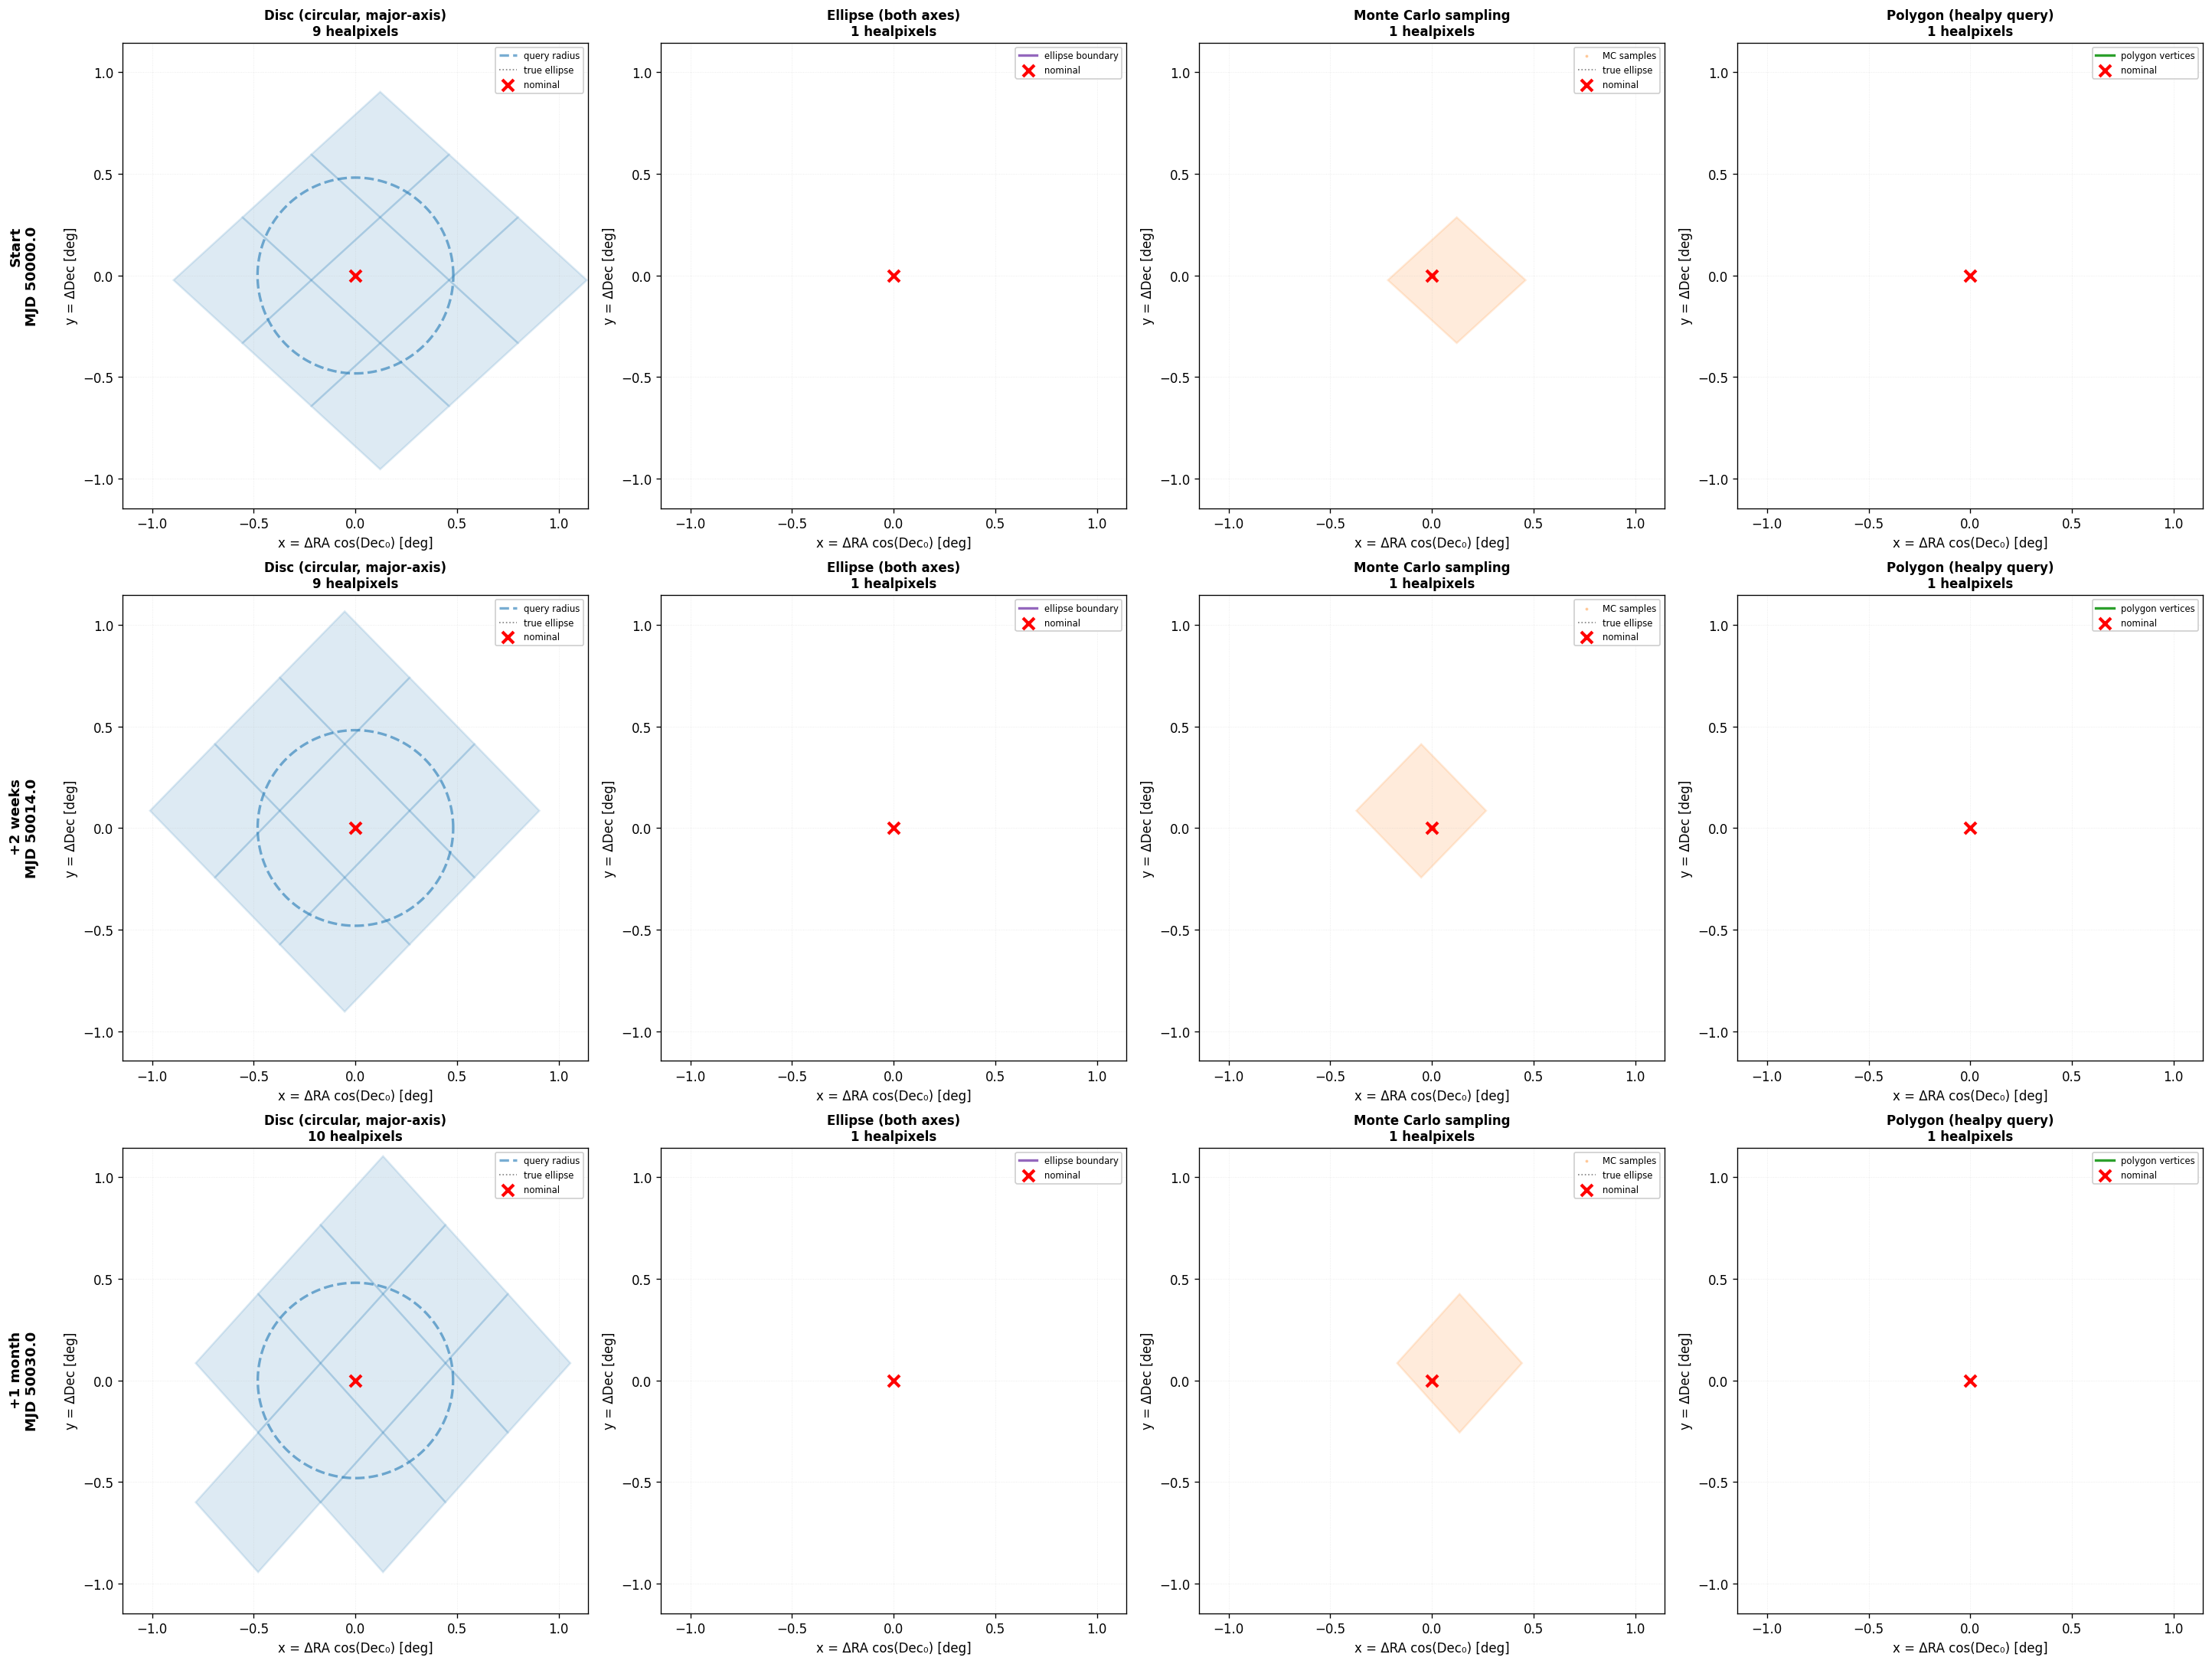


COVARIANCE SCALE VIEW: Showing the physical uncertainty ellipse
NOTE: Zoomed to covariance scale. Healpixels extend far beyond this view.
      Pixel diameter (0.9556°) >> covariance size



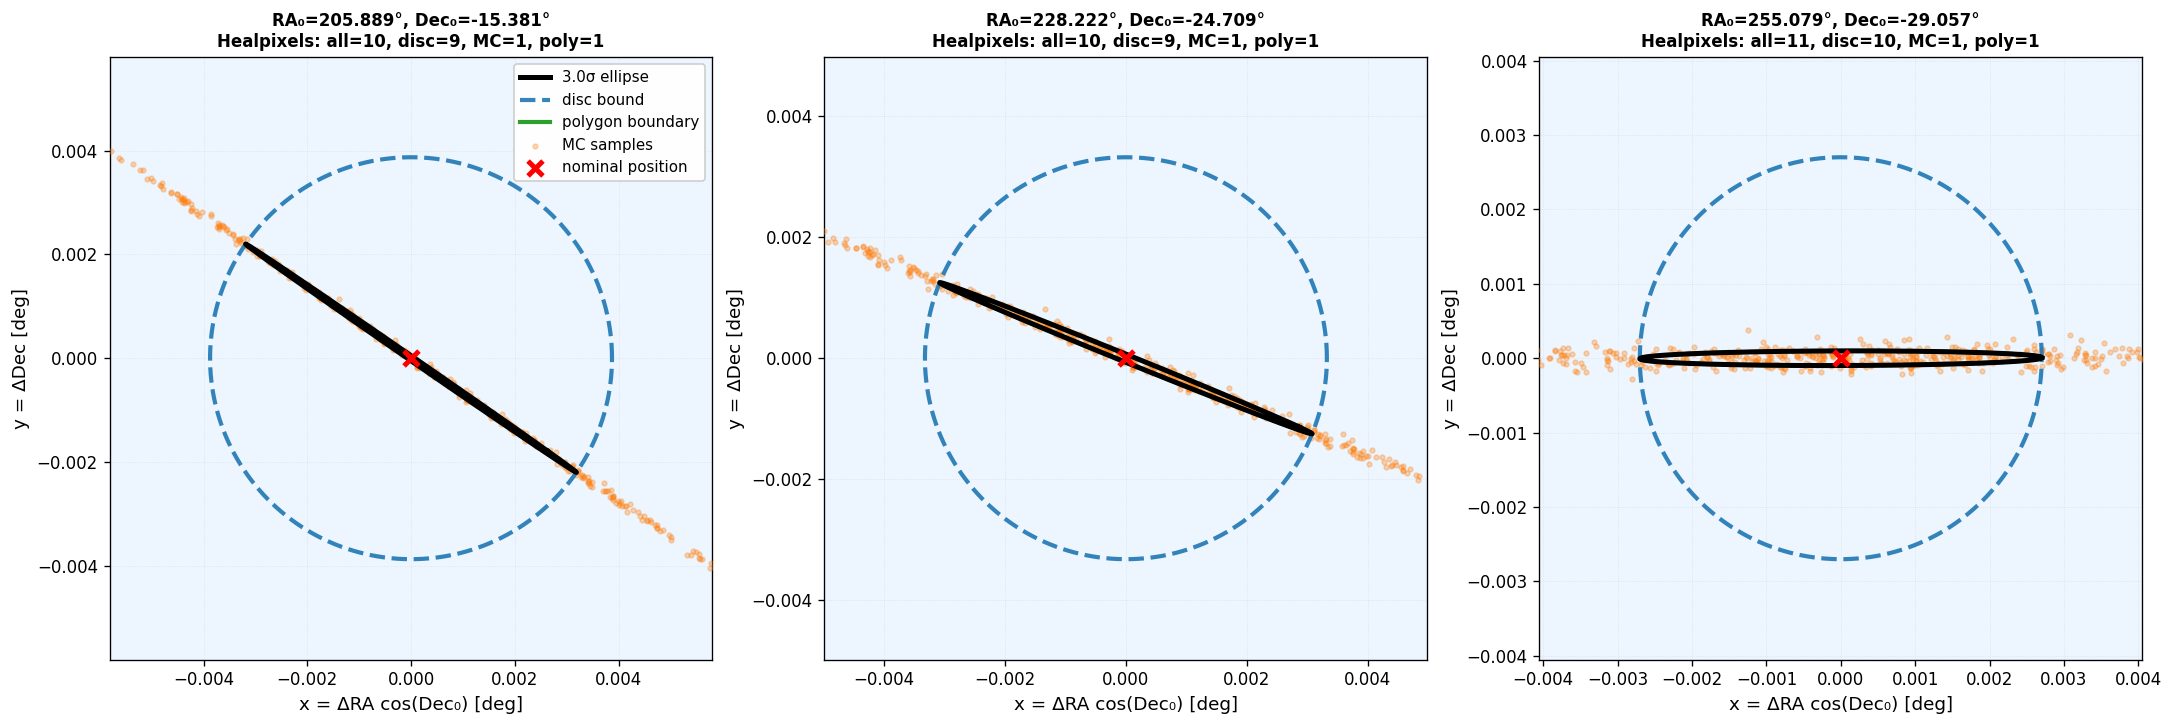

In [45]:
# Run three sample cases: start, +2 weeks, +1 month
# You can tune these knobs.
nside = 128  # smaller pixels (finer grid)
# Controls how "zoomed in" the healpixel plots are:
# - 5 means ~5 pixels across the full width
# - 3 means bigger pixels (more zoomed in)
healpixels_across = 5

n_sigma = 3.0
poly_vertices = 48
mc_samples = 512
mc_seed = 0

cov6 = eph.coordinates.covariance.to_matrix()

print("=" * 80)
print("HEALPIXEL SCALE VIEW: Showing which healpixels are selected")
print("=" * 80)
print(f"HEALPix nside={nside} → pixel diameter ≈ {2*np.rad2deg(hp.max_pixrad(nside)):.4f}°\n")

# For each epoch, show the healpixels selected by each method (4 columns: disc, ellipse, MC, polygon)
fig0, axes0 = plt.subplots(3, 4, figsize=(24, 18), constrained_layout=True)

summary = []
time_labels = ["Start", "+2 weeks", "+1 month"]
for i in range(3):
    lon0 = float(eph.coordinates.lon[i].as_py())
    lat0 = float(eph.coordinates.lat[i].as_py())
    cov_ll = cov6[i, 1:3, 1:3].astype(float)
    
    disc_set, ellipse_set, mc_set, poly_set, r_cov_deg, r_query_deg = plot_case_separated(
        axes0[i],
        lon0,
        lat0,
        cov_ll,
        nside=nside,
        n_sigma=n_sigma,
        num_vertices=poly_vertices,
        mc_samples=mc_samples,
        mc_seed=mc_seed,
        pixels_across=healpixels_across,
    )
    summary.append((mjds[i], len(disc_set), len(ellipse_set), len(mc_set), len(poly_set), r_cov_deg, r_query_deg))
    
    # Add row label
    axes0[i, 0].text(
        -0.18, 0.5, f"{time_labels[i]}\nMJD {mjds[i]:.1f}",
        transform=axes0[i, 0].transAxes,
        fontsize=11, fontweight="bold",
        rotation=90, va="center", ha="right"
    )

print("mjd, #pix(disc), #pix(ellipse), #pix(mc), #pix(polygon), r_cov(deg), r_query(deg)")
for mjd, a, b, c, d, r_cov, r_q in summary:
    print(f"{mjd:.3f}  {a:5d}  {b:5d}  {c:5d}  {d:5d}   {r_cov:.3e}   {r_q:.3e}")

plt.show()

print("\n" + "=" * 80)
print("COVARIANCE SCALE VIEW: Showing the physical uncertainty ellipse")
print("=" * 80)
print("NOTE: Zoomed to covariance scale. Healpixels extend far beyond this view.")
print(f"      Pixel diameter ({2*np.rad2deg(hp.max_pixrad(nside)):.4f}°) >> covariance size\n")

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for i, ax in enumerate(axes1):
    lon0 = float(eph.coordinates.lon[i].as_py())
    lat0 = float(eph.coordinates.lat[i].as_py())
    cov_ll = cov6[i, 1:3, 1:3].astype(float)

    disc_set, mc_set, poly_set, r_cov_deg, r_query_deg = plot_case(
        ax,
        lon0,
        lat0,
        cov_ll,
        nside=nside,
        n_sigma=n_sigma,
        num_vertices=poly_vertices,
        mc_samples=mc_samples,
        mc_seed=mc_seed,
    )

axes1[0].legend(loc="best", fontsize=9, framealpha=0.95)
plt.show()